# 03_supervised.ipynb

Supervised-results reporting notebook for the UN-only regression scope.

- Models: OLS, Ridge, Lasso, RF, GBM
- Feature sets: `numeric_only`, `+tier1`, `+tier2`
- Target: `y_t1_un`


### Hyperparameter Choice Rationale (Fixed Across Feature Tiers)

We use **fixed hyperparameters across `numeric_only`, `+tier1`, and `+tier2`** for each model class to ensure a fair ablation comparison.  
The goal of Q2 is to isolate the effect of adding text features, so we keep model complexity settings constant and change only the input feature set.

#### Why fixed hyperparameters?
- **Comparability:** If hyperparameters were tuned separately by tier, each tier would effectively use a different model instance, making tier-to-tier differences harder to attribute to features alone.
- **Ablation validity:** Fixed settings make the comparison closer to a controlled experiment: same model, different feature blocks.
- **Small-sample stability:** With very limited training years, aggressive per-tier tuning can add variance and overfit validation noise.

#### Chosen values and justification
- **OLS:** default linear regression (no regularization parameter).
- **Ridge (`alpha = 1.0`):** moderate L2 shrinkage; commonly used baseline strength that stabilizes coefficients without overwhelming signal.
- **Lasso (`alpha = 0.01`, `max_iter = 20000`):** mild L1 penalty to encourage sparsity while still allowing informative features to survive; higher `max_iter` ensures convergence in high-dimensional settings.
- **Random Forest (`n_estimators = 200`, `max_depth = 3`):** enough trees for stable averaging, shallow depth limits overfitting in a tiny sample.
- **Gradient Boosting (`n_estimators = 200`, `max_depth = 3`):** moderate ensemble size with constrained tree depth to balance fit and generalization.

#### Additional design choices
- **Standardization for linear models (OLS/Ridge/Lasso):** required so regularization penalties are comparable across differently scaled features.
- **No scaling for tree models (RF/GBM):** tree splits are scale-invariant, so scaling is unnecessary.

This fixed-hyperparameter setup is therefore appropriate for answering the core ablation question: whether richer ECOSOC text representations improve out-of-sample prediction relative to simpler inputs.

In [15]:
# Step 1: Load results
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / 'output').exists():
    ROOT = ROOT.parent

results_path = ROOT / 'output' / 'model_results.csv'
rolling_path = ROOT / 'output' / 'rolling_backtest_summary.csv'
fig_dir = ROOT / 'output' / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

res = pd.read_csv(results_path)
roll = pd.read_csv(rolling_path) if rolling_path.exists() else None

print('Loaded:', results_path)
print('results shape:', res.shape)
print('Columns:', res.columns.tolist())
if roll is not None:
    print('Loaded rolling summary:', rolling_path, 'shape=', roll.shape)
else:
    print('Rolling summary not found (skipping robustness figure).')


Loaded: /Users/enricoalmadani/Desktop/UChicago/Classes/26_Spring_Quarter/BUSN_20800/BUSN-20800-Final-Project-/output/model_results.csv
results shape: (15, 8)
Columns: ['model', 'features', 'target', 'n_features_used', 'n_nonzero_coef', 'rmse', 'mae', 'r2']
Loaded rolling summary: /Users/enricoalmadani/Desktop/UChicago/Classes/26_Spring_Quarter/BUSN_20800/BUSN-20800-Final-Project-/output/rolling_backtest_summary.csv shape= (15, 5)


In [16]:
# Step 2: Clean/sort and show best models
res = res[res['target'] == 'y_t1_un'].copy()
res = res.sort_values('rmse').reset_index(drop=True)

summary_cols = ['model','features','n_features_used','n_nonzero_coef','rmse','mae','r2']
print('Top 10 by RMSE:')
print(res[summary_cols].head(10).to_string(index=False))

best = res.iloc[0][summary_cols]
print('\nBest model row:')
print(best.to_string())

(ROOT / 'output').mkdir(parents=True, exist_ok=True)
res[summary_cols].to_csv(ROOT / 'output' / 'supervised_un_sorted.csv', index=False)
print('Saved:', ROOT / 'output' / 'supervised_un_sorted.csv')


Top 10 by RMSE:
model     features  n_features_used  n_nonzero_coef     rmse      mae        r2
  OLS       +tier2             2014          2008.0 0.094279 0.090805  0.575926
Lasso numeric_only                7             2.0 0.127318 0.084276  0.226627
Lasso       +tier2             2014             5.0 0.140849 0.114586  0.053508
   RF       +tier2             2014             NaN 0.154771 0.134054 -0.142848
  GBM       +tier2             2014             NaN 0.155621 0.133719 -0.155436
   RF numeric_only                7             NaN 0.158121 0.137646 -0.192847
   RF       +tier1               14             NaN 0.163594 0.142623 -0.276852
Lasso       +tier1               14             4.0 0.163618 0.127518 -0.277230
  GBM numeric_only                7             NaN 0.169690 0.143168 -0.373784
Ridge       +tier2             2014          2008.0 0.172045 0.146525 -0.412187

Best model row:
model                   OLS
features             +tier2
n_features_used        2014
n_n

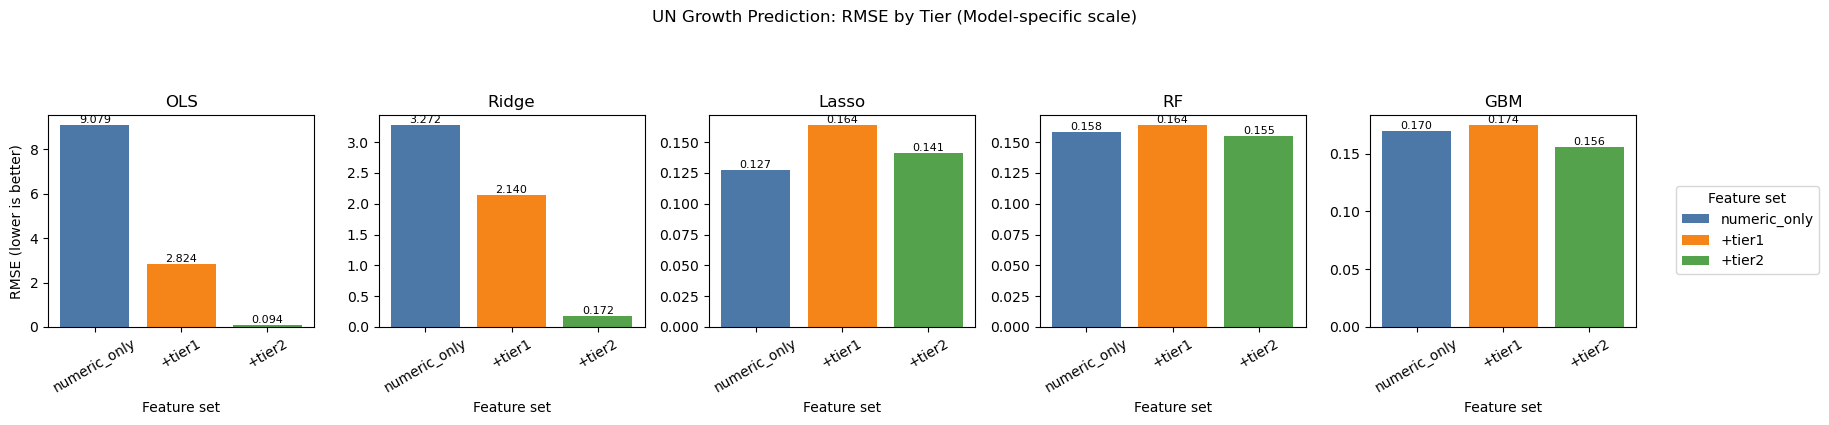

Saved: /Users/enricoalmadani/Desktop/UChicago/Classes/26_Spring_Quarter/BUSN_20800/BUSN-20800-Final-Project-/output/figures/supervised_un_rmse_bars_by_model.png


In [17]:
# Step 3: Figure 1: RMSE by tier with one subplot per model (independent y-scale)
plot_df = res.copy()
order_models = ['OLS','Ridge','Lasso','RF','GBM']
order_tiers = ['numeric_only','+tier1','+tier2']
tier_colors = {'numeric_only': '#4C78A8', '+tier1': '#F58518', '+tier2': '#54A24B'}

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
for ax, model_name in zip(axes, order_models):
    sub = plot_df[plot_df['model'] == model_name].copy()
    sub = sub.set_index('features').reindex(order_tiers).reset_index()

    colors = [tier_colors[t] for t in sub['features']]
    ax.bar(sub['features'], sub['rmse'], color=colors)
    ax.set_title(model_name)
    ax.set_xlabel('Feature set')
    ax.tick_params(axis='x', rotation=30)

    for x, y in zip(range(len(sub)), sub['rmse']):
        if pd.notna(y):
            ax.text(x, y, f'{y:.3f}', ha='center', va='bottom', fontsize=8)

axes[0].set_ylabel('RMSE (lower is better)')
fig.suptitle('UN Growth Prediction: RMSE by Tier (Model-specific scale)', y=1.05)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=tier_colors[t], label=t) for t in order_tiers]
# Place legend outside the plotting area on the right to avoid title overlap
fig.legend(handles=legend_handles, title='Feature set', loc='center left', bbox_to_anchor=(0.93, 0.5))

plt.tight_layout(rect=[0, 0, 0.92, 0.95])
f35 = fig_dir / 'supervised_un_rmse_bars_by_model.png'
plt.savefig(f35, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', f35)


### Key Takeaways  of Figure 1 (RMSE)
- **Best overall RMSE** is `OLS +tier2 = 0.094` (lowest bar in the full figure).
- **Largest tier gain** is for OLS: `9.079` (`numeric_only`) -> `2.824` (`+tier1`) -> `0.094` (`+tier2`), a total drop of **8.985**.
- **Ridge also improves strongly with richer text**: `3.272` -> `2.140` -> `0.172` (total drop **3.100** from numeric to tier2).
- **Tree models improve modestly** with tier2:
  - RF: `0.158` -> `0.164` -> `0.155` (tier2 best, small gain vs numeric: **0.003**).
  - GBM: `0.170` -> `0.174` -> `0.156` (tier2 best, gain vs numeric: **0.014**).
- **Lasso is the exception**: best at `numeric_only = 0.127`, then worse at `+tier1 = 0.164` and `+tier2 = 0.141`.
- Practical read: **Tier2 text usually helps**, but the size of improvement depends heavily on model class.


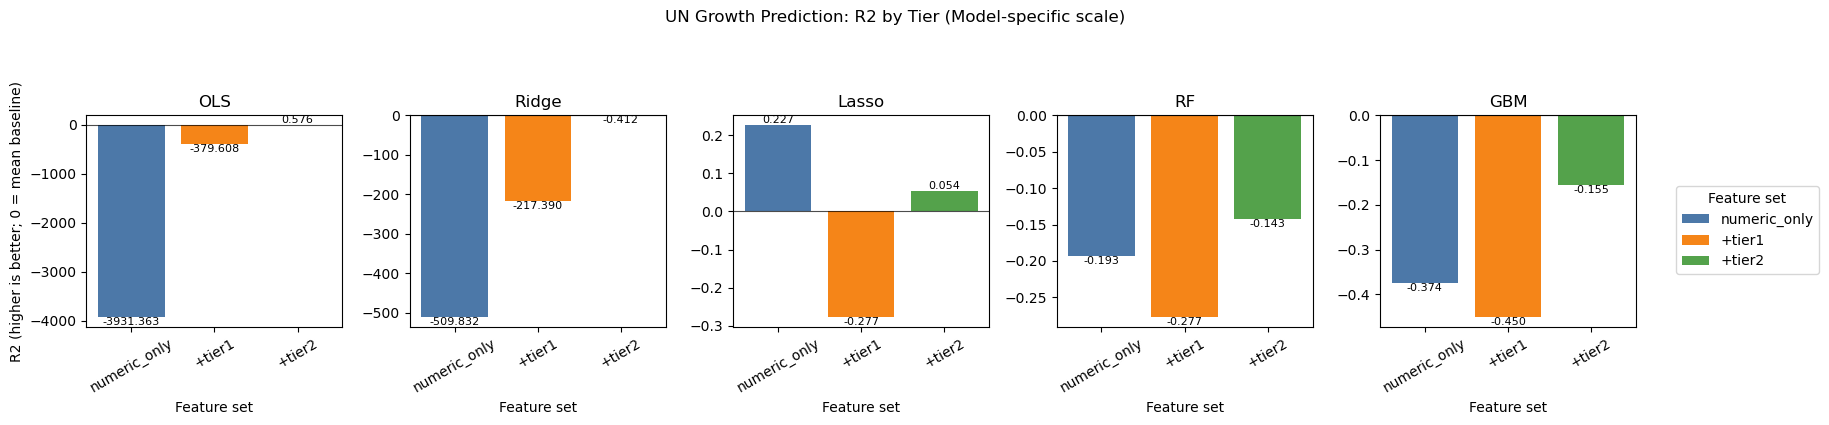

Saved: /Users/enricoalmadani/Desktop/UChicago/Classes/26_Spring_Quarter/BUSN_20800/BUSN-20800-Final-Project-/output/figures/supervised_un_r2_bars_by_model.png


In [18]:
# Step 4: Figure 2 — R2 by tier with one subplot per model
plot_df = res.copy()
order_models = ['OLS','Ridge','Lasso','RF','GBM']
order_tiers = ['numeric_only','+tier1','+tier2']
tier_colors = {'numeric_only': '#4C78A8', '+tier1': '#F58518', '+tier2': '#54A24B'}

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
for ax, model_name in zip(axes, order_models):
    sub = plot_df[plot_df['model'] == model_name].copy()
    sub = sub.set_index('features').reindex(order_tiers).reset_index()

    colors = [tier_colors[t] for t in sub['features']]
    ax.bar(sub['features'], sub['r2'], color=colors)
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.7)
    ax.set_title(model_name)
    ax.set_xlabel('Feature set')
    ax.tick_params(axis='x', rotation=30)

    for x, y in zip(range(len(sub)), sub['r2']):
        if pd.notna(y):
            va = 'bottom' if y >= 0 else 'top'
            ax.text(x, y, f'{y:.3f}', ha='center', va=va, fontsize=8)

axes[0].set_ylabel('R2 (higher is better; 0 = mean baseline)')
fig.suptitle('UN Growth Prediction: R2 by Tier (Model-specific scale)', y=1.05)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=tier_colors[t], label=t) for t in order_tiers]
fig.legend(handles=legend_handles, title='Feature set', loc='center left', bbox_to_anchor=(0.93, 0.5))

plt.tight_layout(rect=[0, 0, 0.92, 0.95])
f2 = fig_dir / 'supervised_un_r2_bars_by_model.png'
plt.savefig(f2, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', f2)


### Key Takeaways of Figure 2 (R2)
- R2 confirms the RMSE story in fit-quality terms: `R2 > 0` means better than mean baseline; `R2 < 0` means worse.
- **OLS and Ridge move from catastrophic negative R² to much better fit at tier2**:
  - OLS: `-3931.363` -> `-379.608` -> `0.576`
  - Ridge: `-509.832` -> `-217.390` -> `-0.412`
- **Lasso has the best simple-model fit** on `numeric_only` (`R² = 0.227`), drops at `+tier1` (`-0.277`), and partially recovers at `+tier2` (`0.054`).
- **RF and GBM stay negative in all tiers**, but tier2 is still their best:
  - RF: `-0.193` -> `-0.277` -> `-0.143`
  - GBM: `-0.374` -> `-0.450` -> `-0.155`
- Bottom line: **Tier2 consistently improves fit for most models**, but only some models (especially OLS and Lasso) cross into positive R² on this fixed split.

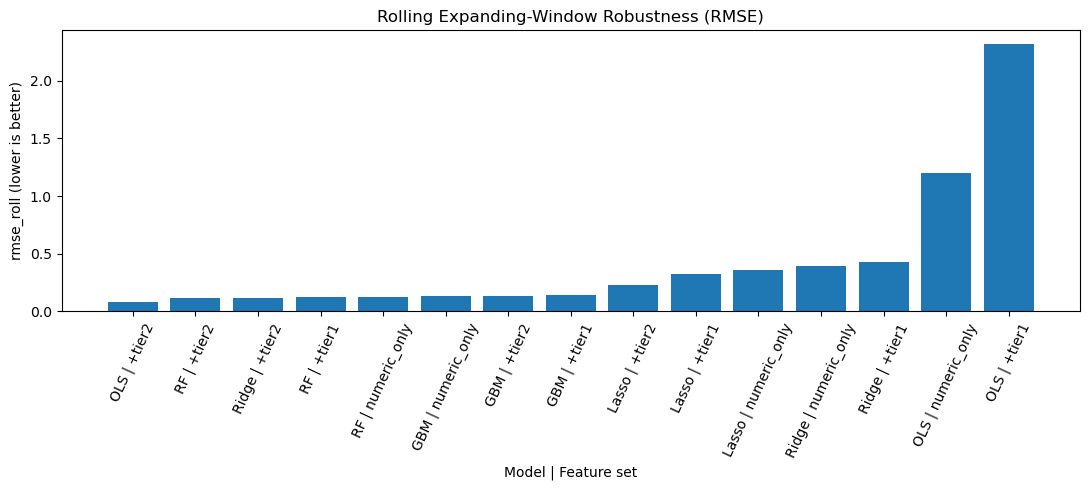

Saved: /Users/enricoalmadani/Desktop/UChicago/Classes/26_Spring_Quarter/BUSN_20800/BUSN-20800-Final-Project-/output/figures/supervised_un_rolling_rmse.png


In [13]:
# Step 5: Figure 3 — Rolling robustness (if available)
if roll is None:
    print('Skipping rolling figure: rolling_backtest_summary.csv not found.')
else:
    r = roll.copy()
    r = r.sort_values('rmse_roll')

    fig, ax = plt.subplots(figsize=(11,5))
    labels = r['model'] + ' | ' + r['features']
    ax.bar(labels, r['rmse_roll'])
    ax.set_title('Rolling Expanding-Window Robustness (RMSE)')
    ax.set_ylabel('rmse_roll (lower is better)')
    ax.set_xlabel('Model | Feature set')
    ax.tick_params(axis='x', rotation=65)
    plt.tight_layout()
    f3 = fig_dir / 'supervised_un_rolling_rmse.png'
    plt.savefig(f3, dpi=160, bbox_inches='tight')
    plt.show()
    print('Saved:', f3)


### Key Takeaways of Figure 3 (Rolling Robustness)
- This robustness test averages one-step-ahead forecast errors across **7 rolling runs** (`n_roll_tests=7` each).
- **Best rolling performer:** `OLS +tier2` (`rmse_roll = 0.080`).
- **Next best cluster:** `RF +tier2` (`0.118`) and `Ridge +tier2` (`0.121`).
- **Tier 2 helps most models in rolling tests:**
  - OLS: `1.204` (`numeric_only`) -> `0.080` (`+tier2`)
  - Ridge: `0.395` -> `0.121`
  - RF: `0.125` -> `0.118`
- **Exception:** GBM is slightly better on `numeric_only` (`0.130`) than `+tier2` (`0.137`).
- Final read: robustness broadly supports a Tier 2 advantage, with some model-specific exceptions.


### Interpretation Notes
- Compare `numeric_only` vs `+tier1` vs `+tier2` to answer Q2 (does richer text help?).
- Use Figure 1 for headline comparison and Figure 2 for quick cross-model pattern reading.
- Use Figure 3 as robustness evidence (stability across rolling forecast windows).
- Keep conclusions directional due to small sample size.


In [14]:
# Step 6: Auto-generated text snippets for paper draft
best = res.loc[res['rmse'].idxmin()]
print('Best point estimate on fixed split:')
print(f"Model={best['model']}, features={best['features']}, RMSE={best['rmse']:.3f}, R2={best['r2']:.3f}")

tier_best = (res.groupby('features', as_index=False)['rmse'].min()
               .sort_values('rmse'))
print('\nBest RMSE within each feature set:')
print(tier_best.to_string(index=False))

if roll is not None:
    rb = roll.loc[roll['rmse_roll'].idxmin()]
    print('\nBest rolling robustness row:')
    print(f"Model={rb['model']}, features={rb['features']}, rmse_roll={rb['rmse_roll']:.3f}, mae_roll={rb['mae_roll']:.3f}")


Best point estimate on fixed split:
Model=OLS, features=+tier2, RMSE=0.094, R2=0.576

Best RMSE within each feature set:
    features     rmse
      +tier2 0.094279
numeric_only 0.127318
      +tier1 0.163594

Best rolling robustness row:
Model=OLS, features=+tier2, rmse_roll=0.080, mae_roll=0.065
